<a href="https://colab.research.google.com/github/brunogk/Bootcamp_ETL/blob/main/Bootcamps_ETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Quantos títulos da netflix que você assiste são filmes e quantos são séries? Qual dia da semana você mais assiste netflix e qual você vê menos? E qual a porcentagem? http://www.harve.com.br/praticas/NetflixViewingHistory.csv

0 : Segunda 1 : Terça 2 : Quarta 3 : Quinta 4 : Sexta 5 : Sábado 6 : Domingo



In [1]:
import pandas as pd

# URL do arquivo CSV fornecida pelo usuário
csv_url = 'http://www.harve.com.br/praticas/NetflixViewingHistory.csv'

# Carregar o arquivo CSV em um DataFrame do pandas de forma a trazer se houve erro ou não
try:
    df = pd.read_csv(csv_url)
    print("Dados carregados com sucesso!")
    # Exibir as primeiras linhas do DataFrame para inspeção
    display(df.head())
except Exception as e:
    print(f"Ocorreu um erro ao carregar os dados: {e}")

Dados carregados com sucesso!


,Title,Date
0,Dentro da Mente de um Gato,23/08/2022
1,A Estrela de Belém,05/08/2022
2,La Bamba,24/07/2022
3,Arremesso Final: Episódio 3,17/07/2022
4,Arremesso Final: Episódio 2,17/07/2022


## Preparação e Limpeza dos Dados

Agora vamos preparar os dados para análise:
1.  Converter a coluna 'Date' para o tipo datetime.
2.  Extrair o dia da semana da coluna 'Date'.
3.  Categorizar cada título como 'Filme' ou 'Série' com base no nome do título. Vamos usar uma heurística simples: se o título contiver 'Temporada' ou 'Episódio', consideraremos uma série. Caso contrário, será um filme.

In [7]:
# 1. Converter a coluna 'Date' para datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remover linhas onde a data não pôde ser convertida (se houver)
df.dropna(subset=['Date'], inplace=True)

# 2. Extrair o dia da semana (0=Segunda, 6=Domingo)
df['DayOfWeek'] = df['Date'].dt.dayofweek

# 3. Categorizar 'Filme' ou 'Série' usando a função do usuário
def classify_type(title):
  if ':' in title:
    return 'Series'
  else:
    return 'Movie'

df['ContentType'] = df['Title'].apply(classify_type)

print("Preparação dos dados concluída.")
display(df.head())

Preparação dos dados concluída.


,Title,Date,DayOfWeek,ContentType,DayName
0,Dentro da Mente de um Gato,2022-08-23,1,Movie,Terça
1,A Estrela de Belém,2022-08-05,4,Movie,Sexta
2,La Bamba,2022-07-24,6,Movie,Domingo
3,Arremesso Final: Episódio 3,2022-07-17,6,Series,Domingo
4,Arremesso Final: Episódio 2,2022-07-17,6,Series,Domingo


## Análise 1: Filmes vs. Séries

Vamos contar quantos títulos são filmes e quantos são séries, e calcular suas respectivas porcentagens.

### Quantidade de Filmes e Séries assistidos:
ContentType
Série    175
Filme    136
Name: count, dtype: int64

### Porcentagem de Filmes e Séries assistidos:
ContentType
Série    56.27%
Filme    43.73%
Name: count, dtype: object


/tmp/ipykernel_1238/2961819422.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=content_counts.index, y=content_counts.values, palette='viridis')


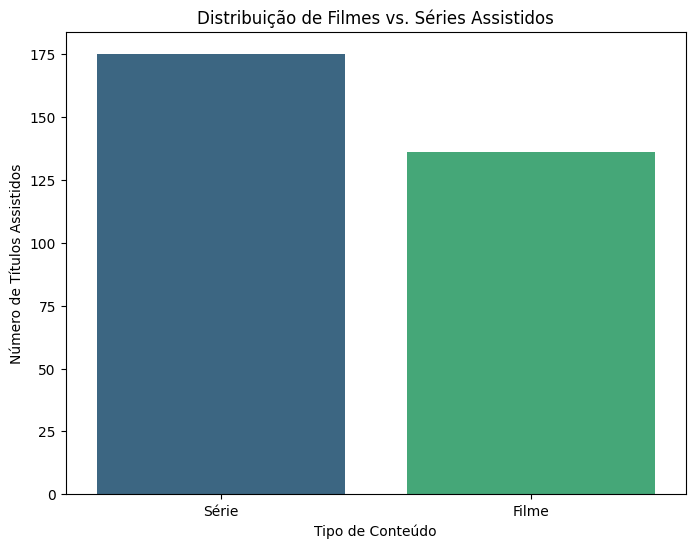

In [3]:
# Contar Filmes e Séries
content_counts = df['ContentType'].value_counts()

# Calcular porcentagens
total_titles = content_counts.sum()
content_percentages = (content_counts / total_titles) * 100

print("### Quantidade de Filmes e Séries assistidos:")
print(content_counts)
print("\n### Porcentagem de Filmes e Séries assistidos:")
print(content_percentages.round(2).astype(str) + '%')

# Opcional: Visualização
import matplotlib.pyplot as plt
import seaborn as sns

fig_content = plt.figure(figsize=(8, 6))
sns.barplot(x=content_counts.index, y=content_counts.values, palette='viridis')
plt.title('Distribuição de Filmes vs. Séries Assistidos')
plt.xlabel('Tipo de Conteúdo')
plt.ylabel('Número de Títulos Assistidos')
plt.show()

## Análise 2: Dia da Semana de Maior e Menor Visualização

Vamos identificar qual dia da semana você mais assiste Netflix e qual dia você assiste menos, além de calcular a porcentagem de visualizações para cada dia.

### Quantidade de Títulos Assistidos por Dia da Semana:
DayName
Segunda      5
Terça       14
Quarta      13
Quinta      19
Sexta       37
Sábado     107
Domingo    116
Name: count, dtype: int64

### Porcentagem de Visualizações por Dia da Semana:
DayName
Segunda     1.61%
Terça        4.5%
Quarta      4.18%
Quinta      6.11%
Sexta       11.9%
Sábado     34.41%
Domingo     37.3%
Name: count, dtype: object

O dia da semana que você mais assiste Netflix é: Domingo (37.3%) 
O dia da semana que você menos assiste Netflix é: Segunda (1.61%) 


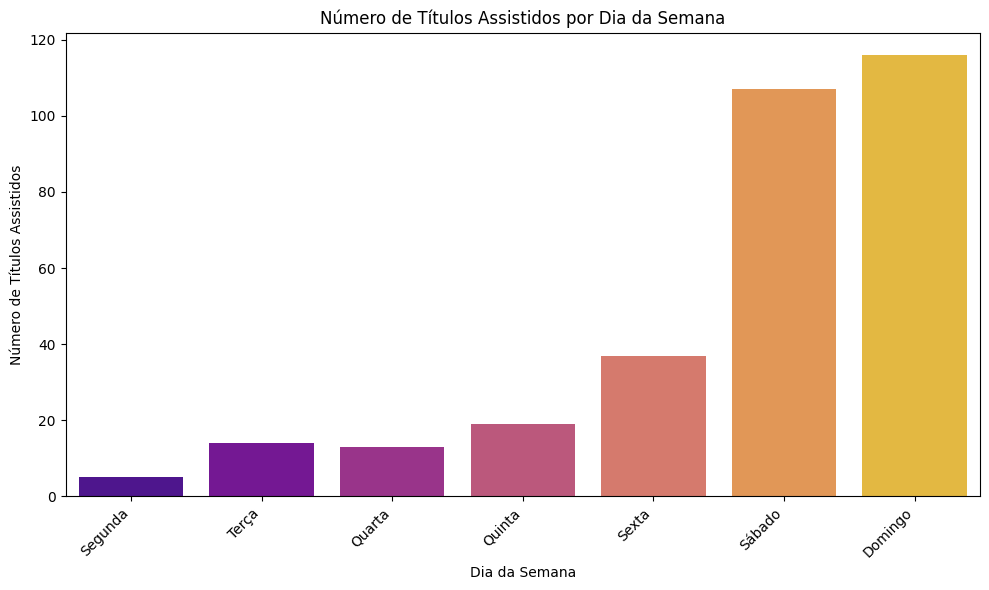

In [6]:
# Mapear números dos dias para nomes para melhor legibilidade
day_names = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
df['DayName'] = df['DayOfWeek'].map(lambda x: day_names[x])

# Contar visualizações por dia da semana
day_counts = df['DayName'].value_counts().reindex(day_names) # Reindexar para garantir a ordem correta

# Calcular porcentagens por dia da semana
total_views = day_counts.sum()
day_percentages = (day_counts / total_views) * 100

print("### Quantidade de Títulos Assistidos por Dia da Semana:")
print(day_counts)
print("\n### Porcentagem de Visualizações por Dia da Semana:")
print(day_percentages.round(2).astype(str) + '%')

# Dia da semana que mais assiste
most_watched_day = day_counts.idxmax()
most_watched_percentage = round(day_percentages.max(), 2)
print(f"\nO dia da semana que você mais assiste Netflix é: {most_watched_day} ({most_watched_percentage}%) ")

# Dia da semana que menos assiste
least_watched_day = day_counts.idxmin()
least_watched_percentage = round(day_percentages.min(), 2)
print(f"O dia da semana que você menos assiste Netflix é: {least_watched_day} ({least_watched_percentage}%) ")

# Opcional: Visualização
import matplotlib.pyplot as plt
import seaborn as sns

fig_day = plt.figure(figsize=(10, 6))
sns.barplot(x=day_counts.index, y=day_counts.values, hue=day_counts.index, palette='plasma', legend=False)
plt.title('Número de Títulos Assistidos por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Número de Títulos Assistidos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Conversão de Moeda (Real para Dólar) com HG Brasil API

Vamos usar a API financeira do HG Brasil para obter a cotação atual do dólar e converter um valor em reais informado pelo usuário.

In [10]:
import requests as r

# URL da API do HG Brasil para finanças (moedas) com a chave da API
# Certifique-se de que a chave '3b9b39d6' é válida ou substitua pela sua chave.
url_fin = 'https://api.hgbrasil.com/finance?key=3b9b39d6'

try:
    response = r.get(url=url_fin)
    response.raise_for_status()  # Levanta um erro para status de resposta HTTP ruins (4xx ou 5xx)
    dados_fin = response.json()

    # Extrair a cotação do dólar (USD) em relação ao real (BRL)
    valor_dolar = dados_fin['results']['currencies']['USD']['buy']

    print(f"Cotação atual do Dólar (compra): R$ {valor_dolar:.2f}")

    # Permitir ao usuário inserir um valor em reais
    while True:
        try:
            valor_real_input = input('Insira aqui o valor em real para converter em dolar: ')
            valor_real = float(valor_real_input)
            break
        except ValueError:
            print("Entrada inválida. Por favor, digite um número.")

    # Realizar a conversão
    valor_convertido = valor_real / valor_dolar

    # Imprimir o resultado
    print(f'O valor convertido é: US$ {valor_convertido:.2f}')

except requests.exceptions.RequestException as e:
    print(f"Ocorreu um erro ao conectar à API do HG Brasil: {e}")
except KeyError:
    print("Não foi possível encontrar os dados da cotação do Dólar na resposta da API. A estrutura da API pode ter mudado ou os dados não estão disponíveis.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

Cotação atual do Dólar (compra): R$ 4.97
Insira aqui o valor em real para converter em dolar: 1415
O valor convertido é: US$ 284.47


Adicione estados unidos, groelandia e canadá no dataframe e salva uma tabela nova com o nome "paises_novos_seunome".

Dica: Use a função concat do pandas para somar seu dataframe novo com o atual do banco de dados.Use o padrão ISO 3166-2.

In [13]:
import pandas as pd

# 1. Criar um novo DataFrame com os países e seus códigos ISO 3166-1 Alpha-2
# Usamos ISO 3166-1 Alpha-2 para países (ex: US para Estados Unidos)
new_countries_data = {
    'Country': ['Estados Unidos', 'Groenlândia', 'Canadá'],
    'ISO_Alpha_2': ['US', 'GL', 'CA']
}
df_new_countries = pd.DataFrame(new_countries_data)

# 2. Salvar o novo DataFrame em um arquivo CSV
# O usuário substitui 'seu_nome' pelo nome desejado no nome do arquivo
file_name = "paises_novos_Bruno.csv"
df_new_countries.to_csv(file_name, index=False)

print(f"O novo DataFrame com os países foi criado e salvo como '{file_name}'.")

# Exibir o novo DataFrame
print("\nDataFrame de novos países:")
display(df_new_countries)

# Nota sobre a concatenação com o DataFrame 'df' original:
# A função `pd.concat` é usada para unir DataFrames. Se a intenção for
# adicionar esses países como novas entradas ao DataFrame 'df' de histórico de visualização,
# seria necessário que as colunas fossem compatíveis ou que se definisse uma lógica
# para preencher as colunas faltantes (Title, Date, etc.) para essas novas linhas.
# Como 'df' e 'df_new_countries' têm estruturas muito diferentes, a concatenação direta
# resultaria em muitas colunas com valores NaN (Not a Number/Não Disponível) em ambos os lados.

O novo DataFrame com os países foi criado e salvo como 'paises_novos_Bruno.csv'.

DataFrame de novos países:


,Country,ISO_Alpha_2
0,Estados Unidos,US
1,Groenlândia,GL
2,Canadá,CA


### Interação com Banco de Dados para Dados de Países

Este código utiliza `SQLAlchemy` para interagir com um banco de dados. Antes de executá-lo, você precisa definir `STRING_DE_CONEXAO` com a string de conexão do seu banco de dados e criar o objeto `engine`.

In [19]:
!pip install pymysql

import pandas as pd
from sqlalchemy import create_engine, text

# Credenciais fornecidas pelo usuário
credenciais = { "username": "alunoharve", "password": "wj7Hs2itAhv$", "hostname": "ip-69-164-197-170.cloudezapp.io", "port": 3306, "database" : "harve_alunos_sql" }
STRING_DE_CONEXAO = "mysql+pymysql://"+credenciais["username"]+":"+credenciais["password"]+"@"+credenciais["hostname"]+":"+str(credenciais["port"])+"/"+credenciais["database"]

# Cria o objeto engine com a STRING_DE_CONEXAO
engine = create_engine(STRING_DE_CONEXAO)

try:
    # Conexão para ler o DataFrame 'df_paises'
    with engine.connect() as conn_obj:
        query = text('SELECT * FROM pais')
        df_paises = pd.read_sql(sql=query, con=conn_obj)
        print("DataFrame 'df_paises' lido do banco de dados:")
        display(df_paises.head())

    # Cria o DataFrame 'df_paises_novos_bruno'
    dict_new_countries = {'id':[24,25,26], 'nome':['Estados Unidos','Groenlândia', 'Canadá'], 'populacao':[349000000,57000,40000000],'codigo':['US','GR','CA']}
    df_paises_novos_bruno = pd.DataFrame(dict_new_countries)
    print("\nDataFrame 'df_paises_novos_bruno' criado:")
    display(df_paises_novos_bruno.head())

    # Salva o DataFrame 'df_paises_novos_bruno' na tabela 'Brunog_paises_novos'
    # 'if_exists='replace'' irá substituir a tabela se ela já existir
    with engine.connect() as conn_obj:
        df_paises_novos_bruno.to_sql(name='Brunog_paises_novos', con=conn_obj, if_exists='replace', index=False)
        conn_obj.commit() # commit é necessário para garantir que as alterações sejam salvas
    print("\nDataFrame 'df_paises_novos_bruno' salvo na tabela 'Brunog_paises_novos'.")

    # Conexão para ler o conteúdo da nova tabela
    with engine.connect() as conn_obj:
        query = text('SELECT * FROM Brunog_paises_novos')
        df_paises_apos_insert = pd.read_sql(sql=query, con=conn_obj)
        print("\nConteúdo da tabela 'Brunog_paises_novos' após inserção:")
        display(df_paises_apos_insert.head())

except Exception as e:
    print(f"Ocorreu um erro ao interagir com o banco de dados: {e}")


DataFrame 'df_paises' lido do banco de dados:


,id,nome,populacao,codigo
0,1,México,129100691,MX
1,2,Colômbia,50500000,CO
2,3,Brasil,212700125,BR
3,4,Nicarágua,6396824,NI
4,5,Panamá,4218808,PA



DataFrame 'df_paises_novos_bruno' criado:


,id,nome,populacao,codigo
0,24,Estados Unidos,349000000,US
1,25,Groenlândia,57000,GR
2,26,Canadá,40000000,CA



DataFrame 'df_paises_novos_bruno' salvo na tabela 'Brunog_paises_novos'.

Conteúdo da tabela 'Brunog_paises_novos' após inserção:


,id,nome,populacao,codigo
0,24,Estados Unidos,349000000,US
1,25,Groenlândia,57000,GR
2,26,Canadá,40000000,CA


In [21]:
df_paises_combinado

,id,nome,populacao,codigo
0,1,México,129100691,MX
1,2,Colômbia,50500000,CO
2,3,Brasil,212700125,BR
3,4,Nicarágua,6396824,NI
4,5,Panamá,4218808,PA
5,6,Chile,19120,CL
6,7,Honduras,9158345,HN
7,8,Cuba,11221,CU
8,9,República Dominicana,10358320,DO
9,10,Peru,33200510,PE


In [18]:
# Concatena df_paises com df_paises_novos_bruno
df_paises_combinado = pd.concat([df_paises, df_paises_novos_bruno], ignore_index=True)

print("\nDataFrame combinado (df_paises + df_paises_novos_bruno):")
display(df_paises_combinado.head(10))

# Opcional: Salvar o DataFrame combinado de volta no banco de dados, se desejado
# Comentado por enquanto para evitar sobrescrever a tabela 'pais' original sem confirmação.
# with engine.connect() as conn_obj:
#     df_paises_combinado.to_sql(name='paises_total_atualizado', con=conn_obj, if_exists='replace', index=False)
#     conn_obj.commit()
# print("\nDataFrame combinado salvo na tabela 'paises_total_atualizado'.")


DataFrame combinado (df_paises + df_paises_novos_bruno):


,id,nome,populacao,codigo
0,1,México,129100691,MX
1,2,Colômbia,50500000,CO
2,3,Brasil,212700125,BR
3,4,Nicarágua,6396824,NI
4,5,Panamá,4218808,PA
5,6,Chile,19120,CL
6,7,Honduras,9158345,HN
7,8,Cuba,11221,CU
8,9,República Dominicana,10358320,DO
9,10,Peru,33200510,PE
